In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from statsmodels.stats.multitest import fdrcorrection
from scipy.stats import chi2, multivariate_normal
from tqdm.notebook import tqdm
sns.set()
#sns.set_style('dark')
sns.set_palette("viridis")

In [2]:
logdiff = pd.read_csv("/Users/taylordinkins/Documents/Research/data/logdiff.csv", delimiter=',')
logdiff_vals = np.loadtxt("/Users/taylordinkins/Documents/Research/data/logdiff_vals.csv", delimiter=',')
date_idx = logdiff['Date']

FileNotFoundError: [Errno 2] No such file or directory: '/Users/taylordinkins/Documents/Research/data/logdiff.csv'

In [438]:
logdiff.shape, logdiff_vals.shape

((1258, 42), (1258, 41))

In [439]:
logdiff.head()

,Date,AAL,AAPL,ALK,AMZN,ASML,AXP,BA,CLX,CSCO,...,PG,PYPL,RCL,SPY,STM,TSLA,TSM,TWTR,VZ,WFC
0,2017-02-23,-0.004004,-0.005499,-0.013683,-0.005016,-0.001719,0.001667,0.008378,-0.000744,-0.001879,...,-0.003840,0.001880,-0.004278,0.000193,0.003787,-0.068387,-0.011073,-0.003717,0.012739,0.002263
1,2017-02-24,0.004654,-0.000308,0.012012,-0.009200,-0.011465,-0.004338,0.003134,0.003886,0.007780,...,-0.001322,0.011907,0.006578,0.000784,-0.012763,0.001750,0.004296,-0.003727,0.005684,-0.011656
2,2017-02-27,0.001621,0.000713,0.008919,0.003004,0.001700,0.004418,0.011013,0.000432,-0.002161,...,-0.002203,-0.010744,0.005709,0.001078,0.033889,-0.044997,-0.013338,0.004391,-0.013193,0.004353
3,2017-02-28,0.001620,-0.000822,0.000196,-0.005262,-0.011210,-0.002082,0.004309,0.002627,-0.002749,...,0.001534,-0.015833,-0.006012,-0.003187,-0.018373,0.012968,-0.002949,-0.018825,-0.006291,-0.003067
4,2017-03-01,0.016381,0.018973,0.024838,0.008458,0.013206,0.022258,0.020073,0.002474,0.007166,...,0.006013,0.009476,0.012621,0.013417,0.026954,-0.002067,0.002445,0.000665,0.003556,0.031501


In [440]:
date_idx

0       2017-02-23
1       2017-02-24
2       2017-02-27
3       2017-02-28
4       2017-03-01
           ...    
1253    2022-02-14
1254    2022-02-15
1255    2022-02-16
1256    2022-02-17
1257    2022-02-18
Name: Date, Length: 1258, dtype: object

In [21]:
from numba import jit

@jit(nopython=True)
def amoc_gen(alarms, first_detect_time, last_detect_time, max_time_detection, thresholds=None):
    """
    Generate an AMOC curve.
    Arguments: 
        alarms: p-vals?
        first_detect_time
        max_time_detection: the maximum number of days to detect a fire (int)
    Returns: 
        FPR_array: false positive rates (list)
        detection_array: days to detection time (list)
    """
    #thresholds = np.arange(0, 1, .001)
    if not thresholds:
        #thresholds = sorted(list(alarms))
        thresholds = sorted(list(alarms.flatten()))
    FPR_array = []
    detection_array = []

    # Check FPR and days to detection for each probability threshold
    for threshold in thresholds:
        detected = False
        detection_time = 0
        false_positives = 0
        true_negatives = 0
        
        for i in range(alarms.shape[0]):
        #for p_value in alarms: # not p-value right now
            
            # Two cases: false positive and true positive
            t_value = alarms[i, :].max()
            if t_value >= threshold:
                if detection_time < first_detect_time or detection_time > last_detect_time: # Check for false positive
                    false_positives += 1
                
                else: # True positive: fire detected
                    detected = True
                    detection_array.append(detection_time - first_detect_time)
                    break
            
            else: # Two cases: false negative and true negative
                if detection_time < first_detect_time: # Check for true negative -- needed for FPR
                    true_negatives += 1
            detection_time += 1

        if false_positives + true_negatives != 0:
            fp_rate = (false_positives) / (false_positives + true_negatives)
            
        else:
            fp_rate = 0
            pass

        FPR_array.append(fp_rate)
        if not detected:
            detection_array.append(max_time_detection)
    
    return FPR_array, detection_array

def apply_fdr_correction(p_vals_all, alpha=0.05):
    corrected_p_vals_all = []
    for i in range(p_vals_all.shape[0]):
        rejected, corrected_p_vals_i = fdrcorrection(p_vals_all[i], alpha=alpha)
        corrected_p_vals_all.append(corrected_p_vals_i)
    return np.array(corrected_p_vals_all)

In [22]:
@jit(nopython=True)
def average_AMOC(AMOC_points):
    """
    Generate an average AMOC curve.
    Arguments: 
        alarms_dataset: List of lists of tuples, where points are FPRs and associated
                        detection times
                        [ [(FPR, detection time), (FPR, detection time)], ...] 
                          [(FPR, detection time), (FPR, detection time)], ...] 
                          ...
                        ]
    Returns: 
        mean_days_per_threshold: list of mean days to detection for each threshold
    """
    mean_days_per_threshold = []
    thresholds = np.arange(0, 1, .0001)
    
    # Find mean detection time for each threshold
    for k in range(len(thresholds)):
        threshold = thresholds[k]
        summed_days = 0
        
        # Approximate detection time for threshold using closest FPR in each simulation
        for i in range(0, len(AMOC_points)):
            current_dataset = AMOC_points[i]  # Get list of alarm values
            closest_pair = current_dataset[0] # Find pair with closest probability threshold
            
            for j in range(0, len(current_dataset)):
                curr_point = current_dataset[j]     # point: (FPR, days to detection)
                if np.abs(curr_point[0] - threshold) < np.abs(closest_pair[0] - threshold):
                    closest_pair = curr_point
            
            # sum the detection times of each dataset that correspond with 
            # probability threshold
            summed_days += closest_pair[1]
        
        mean_days = summed_days / len(AMOC_points)
        mean_days_per_threshold.append(mean_days)
    
    return mean_days_per_threshold, thresholds

In [23]:
def amoc_lrt_vals(lrt_vals, first_possible_detect_time, last_possible_detect_time, thresholds=None):
    # input should be padded vals
    p_vals = np.array([chi2.pdf(lrt_vals[:, i], 2) for i in range(lrt_vals.shape[1])]).T
    p_vals_corrected = apply_fdr_correction(p_vals)
    fprs = []
    detections = []
    fpr_array, detection_array = amoc_gen(lrt_vals, # use LRT vals here
                                          first_detect_time=first_possible_detect_time, 
                                          last_detect_time=last_possible_detect_time, 
                                          max_time_detection=last_possible_detect_time-first_possible_detect_time,
                                          thresholds=thresholds)
    #fprs.append(fpr_array)
    #detections.append(detection_array)
    fpr_result = np.array(fpr_array)
    detect_result = np.array(detection_array)
    #fpr_result = fprs.max(axis=0)
    #detect_result = detections.min(axis=0)
    
    return fpr_result, detect_result
    
def symmetrize_from_vector(a, dim):
    """
    Turns a vector of lower triangular matrix entries into symmetric matrix
    """
    A = np.zeros((dim,dim))
    A[np.tril_indices(A.shape[0], k = 0)] = a
    A = A + A.T - np.diag(np.diag(A))

    return A

def get_h_matrices(full_path, num_mats, dim):
    H_s = []
    for i in range(num_mats):
        H_i = np.loadtxt(os.path.join(full_path, 'matrix_{}.csv'.format(i)))
        H_s.append(symmetrize_from_vector(H_i, dim))
    return np.array(H_s)

In [24]:
@jit(nopython=True)
def indicator_global_stat(p, alpha=0.01):
    q_alpha = -np.log(8*np.pi)-2*np.log(np.log(np.power(1-alpha, -1)))
    threshold = q_alpha+4*np.log(p)-np.log(np.log(p))

    return threshold

@jit(nopython=True)
def amoc_gen_cai(alarms, first_detect_time, last_detect_time, max_time_detection, p):
    """
    Generate an AMOC curve.
    Arguments: 
        alarms: p-vals?
        first_detect_time
        max_time_detection: the maximum number of days to detect a fire (int)
    Returns: 
        FPR_array: false positive rates (list)
        detection_array: days to detection time (list)
    """
    #thresholds = np.arange(0, 1, .001)
    thresholds = sorted(list(alarms))
    #thresholds = sorted(list(np.linspace(alarms.min(), alarms.max(), 6349)))
    print(alarms.min(), alarms.max())
    FPR_array = []
    detection_array = []

    # Check FPR and days to detection for each probability threshold
    for threshold in thresholds:
        #thr = indicator_global_stat(p, alpha=threshold)
        thr = threshold # use the set of possible values
        detected = False
        detection_time = 0
        false_positives = 0
        true_negatives = 0
        for p_value in alarms:
            # Two cases: false positive and true positive
            if p_value >= thr:
                if detection_time < first_detect_time or detection_time > last_detect_time: # Check for false positive
                    false_positives += 1
                
                else: # True positive: fire detected
                    detected = True
                    detection_array.append(detection_time - first_detect_time)
                    break
            
            else: # Two cases: false negative and true negative
                if detection_time < first_detect_time: # Check for true negative -- needed for FPR
                    true_negatives += 1
            detection_time += 1

        if false_positives + true_negatives != 0:
            fp_rate = (false_positives) / (false_positives + true_negatives)
            
        else:
            fp_rate = 0
            pass

        FPR_array.append(fp_rate)
        if not detected:
            detection_array.append(max_time_detection)
    
    return FPR_array, detection_array

def amoc_lrt_vals_cai(lrt_vals, dim, first_possible_detect_time, last_possible_detect_time):
    # input should be padded vals
    #p_vals = np.array([chi2.pdf(lrt_vals[:, i], 2) for i in range(lrt_vals.shape[1])]).T
    fprs = []
    detections = []
    
    fprs, detections = amoc_gen_cai(lrt_vals, 
                                    first_detect_time=first_possible_detect_time, 
                                    last_detect_time=last_possible_detect_time, 
                                    max_time_detection=last_possible_detect_time-first_possible_detect_time,
                                    p=dim)

    fprs = np.array(fprs)
    detections = np.array(detections)
    
    return fprs, detections

In [25]:
#stocks_cpd_path = '/Users/taylordinkins/Documents/Research/CorrCPD/Correlation-Changepoint-Detection/results/lrt_results_v2.csv'
#stocks_xia_path = '/Users/taylordinkins/Documents/Research/CorrCPD/Correlation-Changepoint-Detection/results/global_test_vals_stocks.csv'
curr_seed = 50
stocks_cpd_path='../results/simulation_results/cai_model_three_40/{}/lrt_vals.csv'.format(curr_seed)
stocks_xia_path='../results/simulation_results_cai/cai_model_three_40/{}/global_test_vals.csv'.format(curr_seed)
stocks_cpd = np.loadtxt(stocks_cpd_path, delimiter=',')[:, 6:] # just the p-values
stocks_cpd_stats = np.loadtxt(stocks_cpd_path, delimiter=',')[:, 0:6] # just the stats
stocks_xia = np.loadtxt(stocks_xia_path, delimiter=',')
stocks_cpd.shape, stocks_xia.shape

((400, 6), (400,))

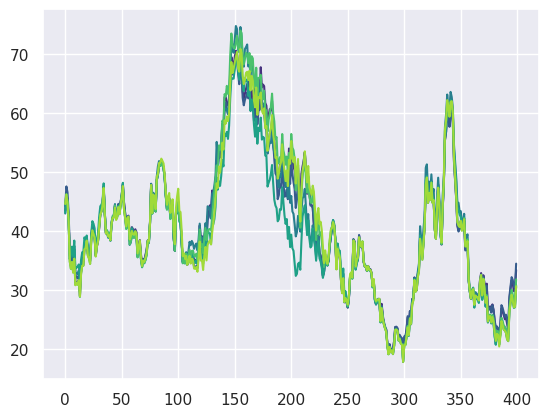

In [26]:
plt.plot(stocks_cpd_stats)

In [27]:
# candidate points
# two from ours, two from Xia
400+125+100, 800+100+130, 633+100, 650+81+100

(625, 1030, 733, 831)

In [28]:
date_idx[625], date_idx[1030], date_idx[733], date_idx[831]

NameError: name 'date_idx' is not defined

In [29]:
# Xia
date_idx[625] # biden-harris nomination 
date_idx[1030] # NY vaccine expansion 30+, George Floyd trial begins
# Ours
date_idx[733] # wuhan quarantine, 3 days after US case
date_idx[831] # early fears of second covid "wave" in news outlets

NameError: name 'date_idx' is not defined

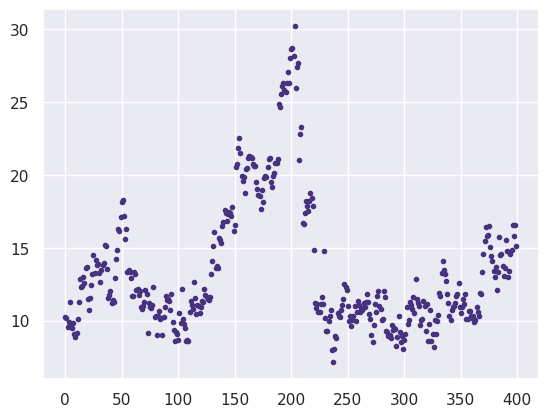

In [30]:
#plt.plot(stocks_cpd_stats[:, 0])
plt.plot(stocks_xia, '.')

0.0 30.23366950731285


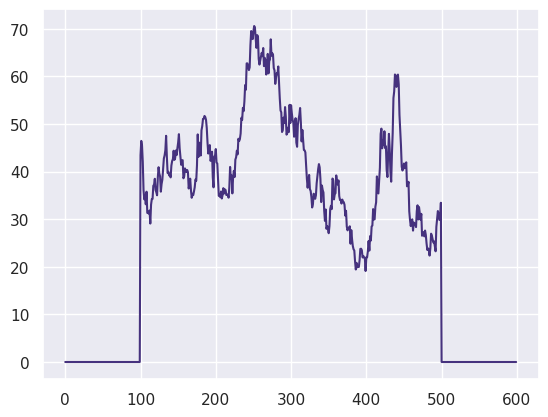

In [31]:
"""
Just stock results
"""
# use t=227 as the changepoint
# no ground truth so it's just a guess from first basis mat
first_d_time = 150-99
last_d_time = 150+100
lrt_result_cpd, detect_result_cpd = amoc_lrt_vals(np.pad(stocks_cpd_stats, [(100, 100), (0,0)], mode='constant'), 
                                                   first_d_time, last_d_time, thresholds=None)
lrt_result_cai, detect_result_cai = amoc_lrt_vals_cai(np.pad(stocks_xia, 100, mode='constant'), 
                                                              first_possible_detect_time=first_d_time,
                                                              last_possible_detect_time=last_d_time,
                                                              dim=41)
plt.plot(np.pad(stocks_cpd_stats, [(100, 100), (0, 0)], mode='constant')[:, 0])

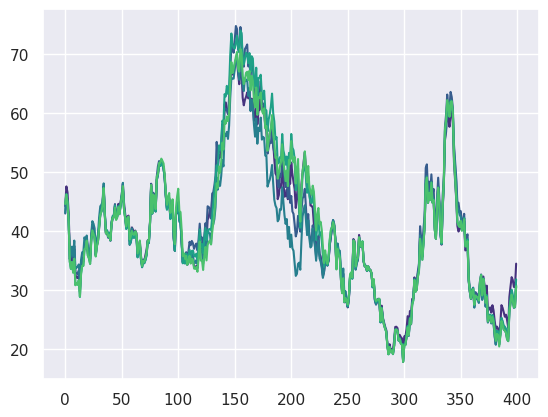

In [32]:
plt.plot(stocks_cpd_stats[:, 1:])

In [33]:
stocks_cpd[:, 0].min()

1.860327657489791e-15

In [34]:
plt.plot(pd.to_datetime(date_idx), np.pad(stocks_cpd_stats, [(100, 100), (0, 0)], mode='constant')[:, 0], '-.b', label='Ours')
plt.plot(pd.to_datetime(date_idx), np.pad(stocks_xia, 100), '-.r', label='Xia')
plt.title('Test Statistics')
plt.legend(loc='best')

NameError: name 'date_idx' is not defined

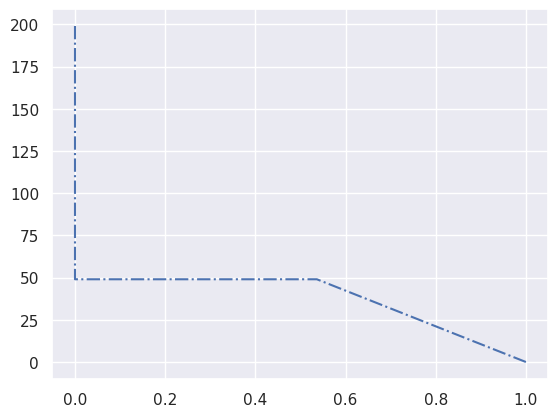

In [35]:
plt.plot(sorted(lrt_result_cai, reverse=True), detect_result_cai, '-.b')

In [36]:
detect_result_cai.shape, lrt_result_cai.shape

((600,), (600,))

In [37]:
detect_result_cpd.shape, lrt_result_cpd.shape

((3600,), (3600,))

In [38]:
detect_result_cai

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [39]:
lrt_result_cai

array([1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

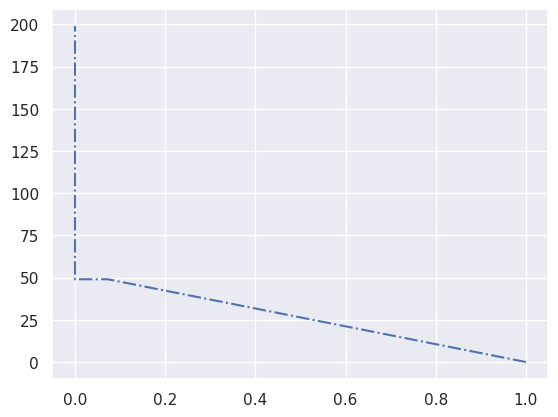

In [40]:
plt.plot(sorted(lrt_result_cpd, reverse=True), detect_result_cpd, '-.b')

In [41]:
detect_result_cpd.shape

(3600,)

In [42]:
lrt_result_cpd.shape

(3600,)

In [43]:
detect_result_cpd

array([  0,   0,   0, ..., 199, 199, 199])

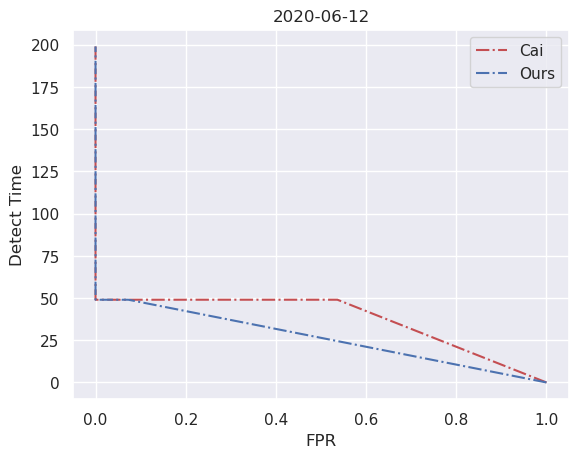

In [44]:
plt.plot(sorted(lrt_result_cai, reverse=True), detect_result_cai, '-.r', label='Cai')
plt.plot(sorted(lrt_result_cpd, reverse=True), detect_result_cpd, '-.b', label='Ours')
plt.ylabel("Detect Time")
plt.xlabel("FPR")
plt.title("Seed {}".format(curr_seed))
plt.legend(loc='best')

In [493]:
sorted(list(set(lrt_cai))) != sorted(list(set(our_lrt)))

NameError: name 'lrt_cai' is not defined

In [ ]:
# amoc curves on mesonet (top level test w/Meinshausen correction)
# run-times on algs
# get FRED data (optional)
# figure out recursive AMOC and base cases for recursion

# slides for Tues!
# ~ 15min
# Meinshausen
# new technical stuff
# add in some AMOC curves and in progress recursive portion
# mesonet AMOC curve
# stock AMOC curve
# chop AMOC at like 0.2 FPR